# ShadowFox Python Development Internship — IPL Fielding Analysis

## Advanced Task 3.1: Cricket Fielding Analysis

This notebook uses the supplied `IPL sample data.xlsx`. The internship task requires ball-level fielding data and a Performance Score (PS). The task document specifies the scoring weights and asks for analysis of three players. The task description is on pages 9–10 of the supplied PDF.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

raw = pd.read_excel('../IPL sample data.xlsx', header=None)
raw.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,Pick,Y->,Clean Pick,N->,Fumble,C->,Catch,DC->,Dropped Catch,S->,Stumping,NaN,NaN
1,Throw,Y->,Good Throw,N->,Bad throw,DH->,Dirct Hit,RO->,Run Out,MR->,Missed Runout,NaN,NaN
2,Runs,"""+"" stands for runs saved ""-"" stands for runs ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,Match No.,Innings,Teams,Player Name,BallCount,Position,Pick,Throw,Runs,Overcount,Venue,Stadium


## 1. Prepare the ball-level dataset

The supplied sample contains 12 ball records. Missing player/event cells are kept as missing rather than inventing information.

In [4]:
ball_cols = ['Match No.','Innings','Team','Player Name','Ballcount','Position','Pick','Throw','Runs','Overcount','Venue','Stadium']
ball_data = raw.iloc[5:17, 1:13].copy()
ball_data.columns = ball_cols
ball_data['Runs'] = pd.to_numeric(ball_data['Runs'], errors='coerce')
ball_data['Overcount'] = pd.to_numeric(ball_data['Overcount'], errors='coerce')
display(ball_data)

,Match No.,Innings,Team,Player Name,Ballcount,Position,Pick,Throw,Runs,Overcount,Venue,Stadium
5,IPL2367,1,Delhi Capitals,Rilee russouw,0.1,Short mid wicket,n,NaN,1.0,1,Delhi,Arun Jaitly Stadium
6,IPL2367,1,Delhi Capitals,Phil Salt,0.2,wicket keeper,Y,Y,NaN,1,Delhi,Arun Jaitly Stadium
7,IPL2367,1,Delhi Capitals,Yash Dhull,0.3,covers,Y,Y,NaN,1,Delhi,Arun Jaitly Stadium
8,IPL2367,1,Delhi Capitals,Axer Patel,0.4,point,Y,Y,NaN,1,Delhi,Arun Jaitly Stadium
9,IPL2367,1,Delhi Capitals,NaN,0.5,NaN,NaN,NaN,NaN,1,Delhi,Arun Jaitly Stadium
10,IPL2367,1,Delhi Capitals,Lalit yadav,0.6,cover point,Y,Y,NaN,1,Delhi,Arun Jaitly Stadium
11,IPL2367,1,Delhi Capitals,Aman Khan,1.1,long off,Y,Y,NaN,2,Delhi,Arun Jaitly Stadium
12,IPL2367,1,Delhi Capitals,NaN,1.2,NaN,NaN,NaN,NaN,2,Delhi,Arun Jaitly Stadium
13,IPL2367,1,Delhi Capitals,Kuldeep yadav,1.3,Short mid wicket,Y,NaN,NaN,2,Delhi,Arun Jaitly Stadium
14,IPL2367,1,Delhi Capitals,NaN,1.4,NaN,NaN,NaN,NaN,2,Delhi,Arun Jaitly Stadium


## 2. Performance Score formula

The supplied sample defines: `PS = CP×1 + GT×1 + C×3 + DC×(-3) + ST×3 + RO×3 + MRO×(-2) + DH×2 + RS`.

In [5]:
matrix_cols = ['Player Name','Clean Picks (CP)','Good Throws (GT)','Catches (C)','Dropped Catches (DC)',
               'Stumpings (ST)','Run Outs (RO)','Missed Run Outs (MRO)','Direct Hits (DH)','Runs Saved (RS)',
               'Performance Score (PS)']
matrix = raw.iloc[22:30, 1:12].copy()
matrix.columns = matrix_cols
for c in matrix_cols[1:]: matrix[c] = pd.to_numeric(matrix[c], errors='coerce')
matrix['Calculated PS'] = (matrix['Clean Picks (CP)'] + matrix['Good Throws (GT)'] + 3*matrix['Catches (C)']
    - 3*matrix['Dropped Catches (DC)'] + 3*matrix['Stumpings (ST)'] + 3*matrix['Run Outs (RO)']
    - 2*matrix['Missed Run Outs (MRO)'] + 2*matrix['Direct Hits (DH)'] + matrix['Runs Saved (RS)'])
matrix['Score Check'] = matrix['Calculated PS'].eq(matrix['Performance Score (PS)'])
display(matrix)

,Player Name,Clean Picks (CP),Good Throws (GT),Catches (C),Dropped Catches (DC),Stumpings (ST),Run Outs (RO),Missed Run Outs (MRO),Direct Hits (DH),Runs Saved (RS),Performance Score (PS),Calculated PS,Score Check
22,Player Name,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
23,Rilee russouw,2.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,2.0,10.0,10.0,True
24,Phil Salt,1.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,-1.0,2.0,2.0,True
25,Yash Dhull,3.0,1.0,2.0,0.0,0.0,0.0,1.0,0.0,3.0,11.0,11.0,True
26,Axer Patel,2.0,3.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,11.0,11.0,True
27,Lalit yadav,1.0,2.0,1.0,0.0,0.0,0.0,0.0,1.0,-2.0,6.0,6.0,True
28,Aman Khan,4.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,9.0,9.0,True
29,Kuldeep yadav,3.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,4.0,9.0,9.0,True


## 3. Select three players

For a reproducible selection, the notebook chooses the three players appearing in the ball-level sample with the highest supplied Performance Score.

In [6]:
eligible = matrix[matrix['Player Name'].isin(ball_data['Player Name'].dropna())]
selected = eligible.sort_values(['Performance Score (PS)','Player Name'], ascending=[False,True]).head(3)
selected_names = selected['Player Name'].tolist()
print('Selected players:', selected_names)
display(selected)

Selected players: ['Axer Patel', 'Yash Dhull', 'Rilee russouw']


,Player Name,Clean Picks (CP),Good Throws (GT),Catches (C),Dropped Catches (DC),Stumpings (ST),Run Outs (RO),Missed Run Outs (MRO),Direct Hits (DH),Runs Saved (RS),Performance Score (PS),Calculated PS,Score Check
26,Axer Patel,2.0,3.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,11.0,11.0,True
25,Yash Dhull,3.0,1.0,2.0,0.0,0.0,0.0,1.0,0.0,3.0,11.0,11.0,True
23,Rilee russouw,2.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,2.0,10.0,10.0,True


## 4. Detailed ball-level records for the selected players

In [7]:
selected_ball_data = ball_data[ball_data['Player Name'].isin(selected_names)]
display(selected_ball_data)

,Match No.,Innings,Team,Player Name,Ballcount,Position,Pick,Throw,Runs,Overcount,Venue,Stadium
5,IPL2367,1,Delhi Capitals,Rilee russouw,0.1,Short mid wicket,n,NaN,1.0,1,Delhi,Arun Jaitly Stadium
7,IPL2367,1,Delhi Capitals,Yash Dhull,0.3,covers,Y,Y,NaN,1,Delhi,Arun Jaitly Stadium
8,IPL2367,1,Delhi Capitals,Axer Patel,0.4,point,Y,Y,NaN,1,Delhi,Arun Jaitly Stadium


## 5. Visual analysis

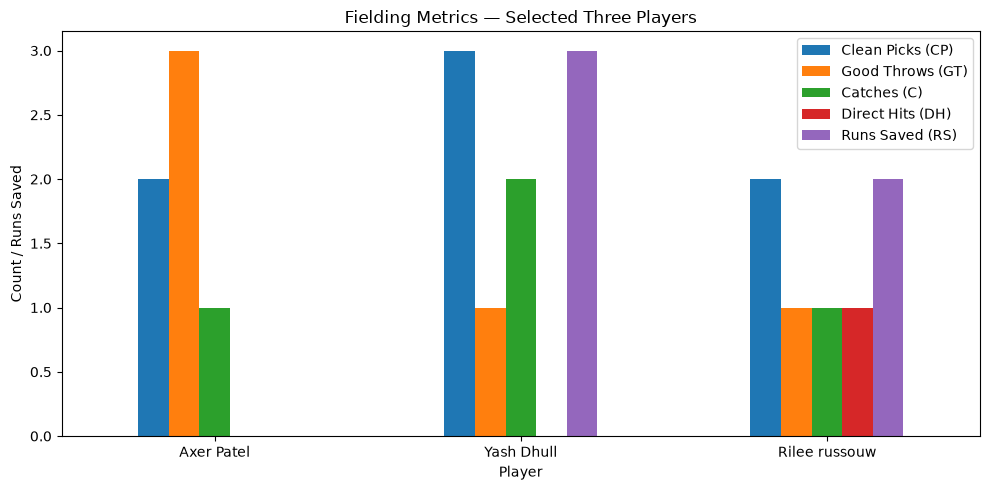

In [8]:
plot_cols = ['Clean Picks (CP)','Good Throws (GT)','Catches (C)','Direct Hits (DH)','Runs Saved (RS)']
selected.set_index('Player Name')[plot_cols].plot(kind='bar', figsize=(10,5))
plt.title('Fielding Metrics — Selected Three Players')
plt.xlabel('Player')
plt.ylabel('Count / Runs Saved')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

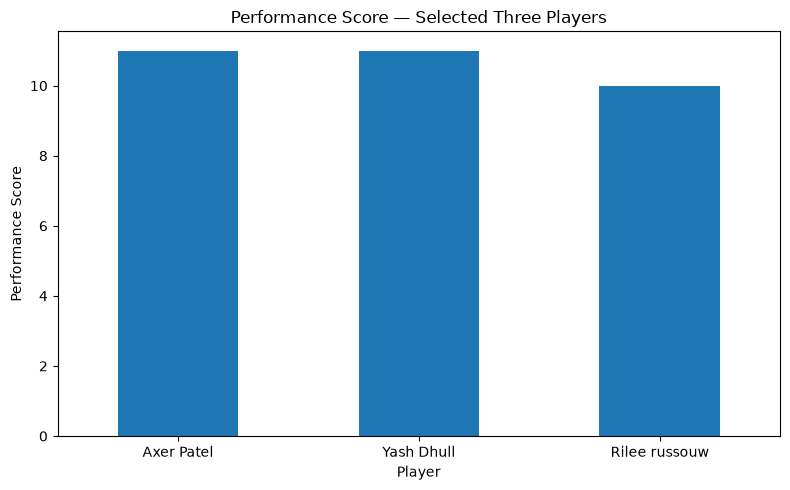

In [9]:
selected.set_index('Player Name')['Performance Score (PS)'].plot(kind='bar', figsize=(8,5))
plt.title('Performance Score — Selected Three Players')
plt.xlabel('Player')
plt.ylabel('Performance Score')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Findings and limitations

The supplied sample shows differences in fielding contributions across the selected players. Performance Score combines positive actions, negative events and runs saved into one metric. These findings are limited to the supplied sample match and should not be generalized to overall IPL or career performance.

## Submission checklist

- Notebook completed
- Cleaned ball-level CSV created
- Performance matrix and score verification created
- Excel workbook created
- Push the project files to GitHub
- Record the required 3–5 minute self-recorded explanation video and submit the Google Drive link as instructed in the task PDF